# Direction split & headway example -- synthetic `shape_test` feed

This notebook builds a tiny, fully synthetic GTFS feed (`examples/test_files/shape_test`)
to demonstrate two `pyGTFSHandler` mechanisms in isolation, without the noise
of a real-world feed:

1. **Direction split** -- how a single physical stop that is served by trips
   travelling in opposite directions gets clustered into distinct
   `shape_direction_id` groups, purely from stop-sequence geometry (no
   `direction_id` or `shapes.txt` required).
2. **Headway (interval) computation** -- `Feed.get_headway_at_stops`, both
   grouped by the GTFS `route_id`/`direction_id` and by the geometric
   `shape_direction` clusters.

## The synthetic network

Six stops laid out in a rough "Y" shape (coordinates are `(lon_offset,
lat_offset)` in hundredths of a degree around a fixed origin):

```
        S1 (1, 2)
         \
          S2 (-1, 1)
         /
   S4 (0,1)
         \
          S3 (0, 0)
         /
   S5 (0,-1)
         |
        S6 (0,-2)
```

Four trips, all on the same `route_id` (`R1`), all frequency-based
(`frequencies.txt`, 07:00-09:00):

| trip | stops                | direction_id | headway |
|------|-----------------------|:---:|:---:|
| T1   | S1 -> S2 -> S3 -> S4        | 0 | 10 min |
| T2   | S4 -> S3 -> S2 -> S1        | 1 | 10 min |
| T3   | S1 -> S2 -> S3 -> S5 -> S6  | 0 | 15 min |
| T4   | S6 -> S5 -> S3 -> S2 -> S1  | 1 | 15 min |

T1/T3 travel "outbound" (S1 towards S4/S6); T2/T4 are their exact reverse.
S2 and S3 are shared by *all four* trips, so they are the interesting stops
for the direction-split demo below.

In [1]:
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pyGTFSHandler import Feed

# The synthetic feed lives at examples/test_files/shape_test. Resolve it
# relative to this notebook's own location, not the kernel's working
# directory (which varies by launcher: plain `jupyter notebook` uses the
# repo root, VS Code / some IDEs start the kernel in examples/).
for candidate in (Path.cwd() / "test_files" / "shape_test", Path.cwd() / "examples" / "test_files" / "shape_test"):
    if candidate.is_dir():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find test_files/shape_test relative to the current working "
        f"directory ({Path.cwd()}) -- run this notebook from the repo root or from examples/"
    )

feed = Feed(DATA_DIR)

service_date = datetime.date(2026, 8, 3)
start_time = datetime.time(7, 0)
end_time = datetime.time(9, 0)

## 1. The raw network, before any direction split

First, let's plot the four trips as-is: one line per trip, coloured by
`direction_id`. Every stop is a single point at this stage -- `stops.txt`
has no notion of direction.

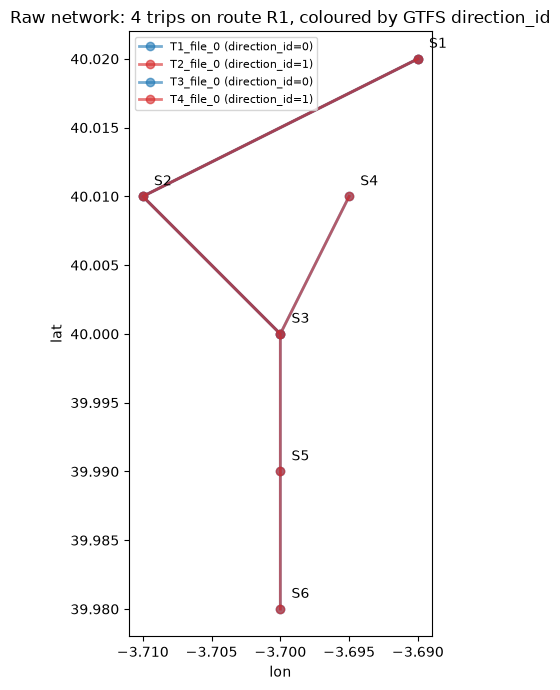

In [2]:
stops_gdf = feed.stops.gdf.copy()
stops_gdf["lon"] = stops_gdf.geometry.x
stops_gdf["lat"] = stops_gdf.geometry.y
stop_coords = dict(zip(stops_gdf["stop_id"], zip(stops_gdf["lon"], stops_gdf["lat"])))

stop_times_df = (
    feed.stop_times.lf.sort(["trip_id", "stop_sequence"]).collect()
)
trips_df = feed.trips.lf.collect()

trip_directions = dict(zip(trips_df["trip_id"], trips_df["direction_id"]))

fig, ax = plt.subplots(figsize=(6, 7))
dir_colors = {0: "tab:blue", 1: "tab:red"}

for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    trip_id = trip_id[0]
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] for s in group["stop_id"]]
    direction_id = trip_directions[trip_id]
    ax.plot(
        xs, ys, "-o",
        color=dir_colors[direction_id],
        alpha=0.6,
        linewidth=2,
        markersize=6,
        label=f"{trip_id} (direction_id={direction_id})",
    )

for stop_id, (lon, lat) in stop_coords.items():
    ax.annotate(stop_id.replace("_file_0", ""), (lon, lat), textcoords="offset points", xytext=(8, 8))

ax.set_title("Raw network: 4 trips on route R1, coloured by GTFS direction_id")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. Headway grouped by `route_id` / GTFS `direction_id`

`Feed.get_headway_at_stops` computes the harmonic-mean headway of departures
at each stop within a time window. With `by="route_id"` it groups services
using the GTFS `route_id` + `direction_id` columns directly -- this only
works because our synthetic feed happens to set `direction_id` consistently.
Many real-world feeds leave `direction_id` null or inconsistent, which is
exactly the problem the geometric `shape_direction` method (next section)
is designed to work around.

`how="all"` returns one row per stop/route/direction combination.

In [3]:
headway_by_route = feed.get_headway_at_stops(
    service_date,
    start_time=start_time,
    end_time=end_time,
    by="route_id",
    at="parent_station",
    how="all",
)

headway_by_route.select(["parent_station", "route_id", "direction_id", "headway"]).sort("parent_station")

parent_station,route_id,direction_id,headway
str,str,i64,f64
"""S1_file_0""","""R1_file_0""",0,8.333333
"""S2_file_0""","""R1_file_0""",0,8.333333
"""S2_file_0""","""R1_file_0""",1,7.533333
"""S3_file_0""","""R1_file_0""",1,7.533333
"""S3_file_0""","""R1_file_0""",0,8.333333
"""S4_file_0""","""R1_file_0""",1,10.0
"""S5_file_0""","""R1_file_0""",1,15.0
"""S5_file_0""","""R1_file_0""",0,15.0
"""S6_file_0""","""R1_file_0""",1,15.0


## 3. Direction split via `shape_direction`

With `by="shape_direction"`, each stop-visit is first tagged with a bearing
(`shape_direction`, degrees from north) computed from the stop's position
relative to the other stops on the *same trip pattern* -- so it needs no
`direction_id` and no `shapes.txt`. For every physical stop, the bearings of
all its visits are then clustered into `n_divisions * 2` angular bins
(`n_divisions=1` -> 2 bins: "forward" vs "backward") by finding the widest
angular gap between observed bearings and splitting on it
(`shape_direction_id`).

This is the mechanism the notebook's title refers to as the "direction
split": a single `stop_id` becomes multiple `(stop_id, shape_direction_id)`
rows, each with its own headway.

In [4]:
from pyGTFSHandler.utils import geo_polars

headway_by_shape = feed.get_headway_at_stops(
    service_date,
    start_time=start_time,
    end_time=end_time,
    by="shape_direction",
    at="stop_id",
    n_divisions=1,
    how="all",
)

split_table = headway_by_shape.select(
    ["stop_id", "shape_direction_id", "shape_direction", "headway", "route_ids"]
).sort(["stop_id", "shape_direction_id"])

# The line that separates direction 0 from direction 1 at a stop is
# perpendicular to the (opposing) mean travel bearings observed there --
# i.e. the same "widest angular gap" split the library itself computes
# internally to assign shape_direction_id, recovered here from the
# per-direction mean bearings for plotting. Stops with only one observed
# direction have no real split (nothing to separate), so `n_directions`
# is kept to filter those out later.
split_lines = (
    split_table.group_by("stop_id")
    .agg(pl.col("shape_direction").alias("shape_direction"), pl.len().alias("n_directions"))
)
split_lines = split_lines.with_columns(
    geo_polars.max_separation_angle(split_lines, "shape_direction").alias("split_direction")
)
split_lines

stop_id,shape_direction,n_directions,split_direction
str,list[f64],u32,f64
"""S1_file_0""",[208.570958],1,118.570958
"""S2_file_0""","[185.4845, 5.4845]",2,275.4845
"""S3_file_0""","[130.791014, 310.791014]",2,220.791014
"""S4_file_0""",[270.001607],1,180.001607
"""S5_file_0""","[360.0, 180.0]",2,270.0
"""S6_file_0""",[0.0],1,90.0


In [5]:
# Per-trip raw bearings, before any clustering: one row per (trip, stop)
# visit, so the same physical stop shows a different arrow for each trip
# that passes it, even trips assigned to the same shape_direction_id (they
# rarely share the exact same bearing -- e.g. T1's S1->S2->S3->S4 vs T3's
# S1->S2->S3->S5->S6 diverge after S3, so their bearing at S1/S2 differs
# slightly). The last stop of a trip has no *forward* bearing (there's no
# next stop), so it falls back to the reverse of its *backward* bearing.
# `direction_id` (the GTFS field) is attached too, so it can be compared
# against the geometric `shape_direction_id` clustering in the plot below.
trip_bearings = (
    feed.filter(date=service_date, start_time=start_time, end_time=end_time)
    .select(["trip_id", "stop_id", "shape_direction", "shape_direction_backwards"])
    .unique()
    .with_columns(
        pl.when(pl.col("shape_direction").is_finite() & pl.col("shape_direction").is_not_null())
        .then(pl.col("shape_direction"))
        .otherwise((pl.col("shape_direction_backwards") + 180) % 360)
        .alias("trip_bearing")
    )
    .drop_nulls("trip_bearing")
    .filter(pl.col("trip_bearing").is_finite())
    .with_columns(pl.col("trip_id").replace(trip_directions).cast(int).alias("direction_id"))
    .sort(["stop_id", "trip_id"])
    .collect()
)
trip_bearings

trip_id,stop_id,shape_direction,shape_direction_backwards,trip_bearing,direction_id
str,str,f64,f64,f64,i64
"""T1_file_0""","""S1_file_0""",213.832083,NaN,213.832083,0
"""T2_file_0""","""S1_file_0""",NaN,213.832083,33.832083,1
"""T3_file_0""","""S1_file_0""",200.959866,NaN,200.959866,0
"""T4_file_0""","""S1_file_0""",NaN,200.959866,20.959866,1
"""T1_file_0""","""S2_file_0""",117.570458,56.855177,117.570458,0
…,…,…,…,…,…
"""T2_file_0""","""S4_file_0""",270.001607,NaN,270.001607,1
"""T3_file_0""","""S5_file_0""",180.0,360.0,180.0,0
"""T4_file_0""","""S5_file_0""",360.0,180.0,360.0,1


In [6]:
with pl.Config(tbl_rows=-1):
    print(trip_bearings)

shape: (18, 6)
┌───────────┬───────────┬─────────────────┬──────────────────────────┬──────────────┬──────────────┐
│ trip_id   ┆ stop_id   ┆ shape_direction ┆ shape_direction_backward ┆ trip_bearing ┆ direction_id │
│ ---       ┆ ---       ┆ ---             ┆ s                        ┆ ---          ┆ ---          │
│ str       ┆ str       ┆ f64             ┆ ---                      ┆ f64          ┆ i64          │
│           ┆           ┆                 ┆ f64                      ┆              ┆              │
╞═══════════╪═══════════╪═════════════════╪══════════════════════════╪══════════════╪══════════════╡
│ T1_file_0 ┆ S1_file_0 ┆ 213.832083      ┆ NaN                      ┆ 213.832083   ┆ 0            │
│ T2_file_0 ┆ S1_file_0 ┆ NaN             ┆ 213.832083               ┆ 33.832083    ┆ 1            │
│ T3_file_0 ┆ S1_file_0 ┆ 200.959866      ┆ NaN                      ┆ 200.959866   ┆ 0            │
│ T4_file_0 ┆ S1_file_0 ┆ NaN             ┆ 200.959866               ┆ 20.95

Notice that `S2` and `S3` (visited by trips going both ways) each get **two**
rows -- one per `shape_direction_id` -- while a terminal-like stop such as
`S1` still only appears once per direction it actually sees traffic in.
The two bins per stop are roughly 180 degrees apart, confirming the split
correctly separates "towards S4/S6" from "towards S1".

## 4. Plotting the split: per-trip bearings, the clustered arrows, and the split line

Three layers, smallest/most granular first:

- **Thin, short, semi-transparent arrows** -- one per `(trip_id, stop_id)`
  visit, coloured by `trip_id`. These are the *raw* bearings before any
  clustering -- T1 and T3 both pass S1/S2 travelling "outbound" but along
  slightly different bearings (they diverge after S3), so even trips
  sharing a `shape_direction_id` don't perfectly overlap.
- **Larger, solid arrows** -- one per `(stop_id, shape_direction_id)`, at
  the mean bearing of the trips clustered into that bin, labelled with the
  resulting headway in minutes. Stops with only one direction bin (no
  meaningful split) show a single such arrow.
- **Dashed black line** -- at stops with two direction bins, drawn through
  the stop along `split_direction`, the angular boundary the library uses
  to decide which cluster (dir 0 vs dir 1) a given bearing belongs to. It
  runs perpendicular to the two (opposing) mean travel bearings, visually
  "cutting" the stop into its two directions.

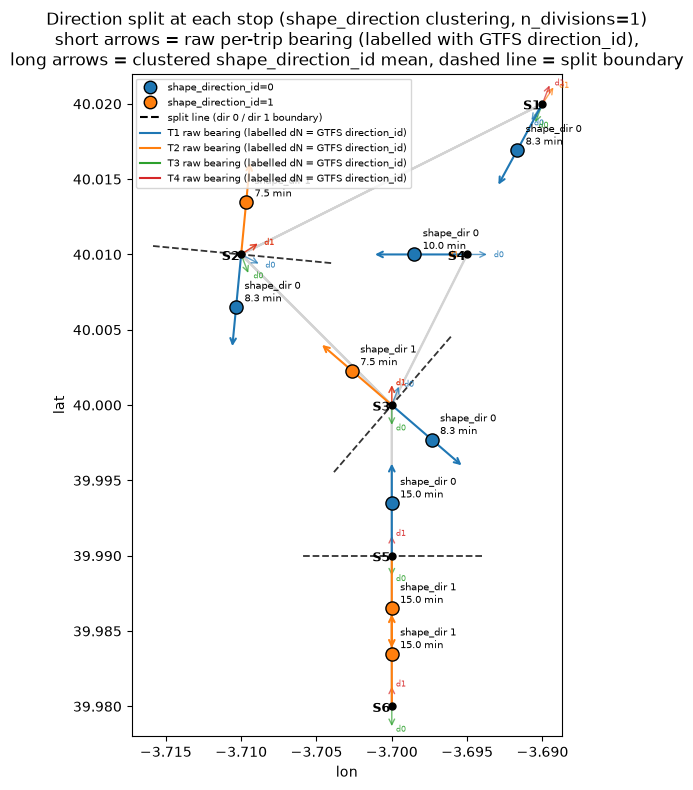

In [7]:
TRIP_OFFSET_DEG = 0.0015  # short arrow length for individual per-trip bearings
OFFSET_DEG = 0.0035  # how far to nudge each clustered direction marker from the stop, in degrees
LINE_HALF_LEN_DEG = 0.006  # half-length of the split line drawn through each stop
dir_id_colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green", 3: "tab:purple"}
trip_ids_sorted = sorted(trip_bearings["trip_id"].unique().to_list())
trip_colors = dict(zip(trip_ids_sorted, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(7, 8))

# Faint underlay of the raw trip paths for context.
for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] for s in group["stop_id"]]
    ax.plot(xs, ys, "-", color="lightgray", linewidth=1.5, zorder=1)

# Split line: dashed, drawn through the stop along `split_direction`, only
# for stops that actually have two direction bins to separate.
for row in split_lines.filter(pl.col("n_directions") > 1).iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    split_rad = np.deg2rad(row["split_direction"])
    ldx = np.sin(split_rad) * LINE_HALF_LEN_DEG
    ldy = np.cos(split_rad) * LINE_HALF_LEN_DEG
    ax.plot(
        [lon - ldx, lon + ldx], [lat - ldy, lat + ldy],
        "--", color="black", linewidth=1.3, zorder=2, alpha=0.8,
    )

# Per-trip raw bearings: small, short, semi-transparent arrows, one per
# (trip_id, stop_id) visit -- shown *underneath* the clustered arrows so
# their spread around each cluster's mean bearing is visible. Each arrow
# is labelled with the trip's GTFS `direction_id` ("d0"/"d1"), so you can
# compare it against the geometric `shape_direction_id` clustering shown
# by the larger arrows/markers below.
for row in trip_bearings.iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    bearing_rad = np.deg2rad(row["trip_bearing"])
    dx = np.sin(bearing_rad) * TRIP_OFFSET_DEG
    dy = np.cos(bearing_rad) * TRIP_OFFSET_DEG
    color = trip_colors[row["trip_id"]]
    ax.annotate(
        "",
        xy=(lon + dx, lat + dy),
        xytext=(lon, lat),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.0, alpha=0.7),
        zorder=2,
    )
    ax.annotate(
        f"d{row['direction_id']}",
        (lon + dx, lat + dy),
        textcoords="offset points",
        xytext=(3, -2),
        fontsize=6,
        color=color,
        alpha=0.9,
    )

for row in split_table.iter_rows(named=True):
    stop_id = row["stop_id"]
    lon, lat = stop_coords[stop_id]
    bearing_rad = np.deg2rad(row["shape_direction"])
    dx = np.sin(bearing_rad) * OFFSET_DEG
    dy = np.cos(bearing_rad) * OFFSET_DEG

    marker_lon, marker_lat = lon + dx, lat + dy
    color = dir_id_colors.get(row["shape_direction_id"], "gray")

    ax.scatter([marker_lon], [marker_lat], color=color, s=90, zorder=3, edgecolor="black")
    ax.annotate(
        "",
        xy=(lon + dx * 1.8, lat + dy * 1.8),
        xytext=(lon, lat),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
        zorder=2,
    )
    ax.annotate(
        f"shape_dir {row['shape_direction_id']}\n{row['headway']:.1f} min",
        (marker_lon, marker_lat),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=7.5,
    )

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=25, zorder=4)
    ax.annotate(
        stop_id.replace("_file_0", ""),
        (lon, lat),
        textcoords="offset points",
        xytext=(-14, -4),
        fontsize=9,
        fontweight="bold",
    )

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markeredgecolor="black", markersize=9, label=f"shape_direction_id={d}")
    for d, c in dir_id_colors.items()
    if d in split_table["shape_direction_id"].to_list()
]
handles.append(plt.Line2D([0], [0], linestyle="--", color="black", label="split line (dir 0 / dir 1 boundary)"))
handles += [
    plt.Line2D([0], [0], color=trip_colors[t], lw=1.5, label=f"{t.replace('_file_0', '')} raw bearing (labelled dN = GTFS direction_id)")
    for t in trip_ids_sorted
]
ax.legend(handles=handles, loc="upper left", fontsize=7)
ax.set_title(
    "Direction split at each stop (shape_direction clustering, n_divisions=1)\n"
    "short arrows = raw per-trip bearing (labelled with GTFS direction_id),\n"
    "long arrows = clustered shape_direction_id mean, dashed line = split boundary"
)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Takeaways

- `S3` and `S2` -- shared by both the S1<->S4 and S1<->S6 services in both
  directions -- are split into two `shape_direction_id` clusters roughly
  180 degrees apart, each combining the headways of the trips passing that way
  (harmonic mean, so a 10-min and a 15-min service combine to a shorter
  effective headway than either alone).
- Terminal-ish stops (`S1`, `S4`, `S6`) mostly see traffic from one bearing
  per direction bin, so their split mirrors the simpler `route_id`/`direction_id`
  grouping from Section 2 -- but the `shape_direction` method reaches the
  same conclusion **without needing a reliable `direction_id`**, which is
  the main reason to prefer it for messy real-world feeds.
- Increasing `n_divisions` (e.g. to 2) would instead split each stop into 4
  angular bins, useful for stops where more than two travel directions
  genuinely meet (e.g. a junction stop).

## 5. `Shapes.assign_direction_ids`: a route-wide, branch-aware `direction_id`

Sections 3-4 used `get_headway_at_stops(by="shape_direction")`, which
clusters bearings *independently at each stop* -- the resulting
`shape_direction_id` numbering (0 vs 1) has no relationship from one stop
to the next. `pyGTFSHandler.models.shapes.Shapes.assign_direction_ids` builds
on the same per-stop bearings but reconciles them into one consistent
`direction_id` per `shape_id` across an entire route, even through a branch
point like `S3` -- see the module docstring for the full algorithm (anchor
stop = the one with the most distinct `shape_id`s; smaller stops are then
folded in ascending order of shape-id count, choosing whichever orientation
agrees with the most already-resolved shapes; genuine conflicts set a
per-row boolean `direction_id_issues` flag rather than silently overwriting
an established value).

Rather than a separate table, this is integrated directly into
`feed.shapes.stop_shapes` -- the same one-row-per-`(shape_id, stop_id)`
geometry table used above, now with `route_id`, `direction_id`, and
`direction_id_issues` added alongside the untouched raw
`shape_direction`/`shape_direction_backwards` bearings:

In [ ]:
stop_shapes_df = (
    feed.shapes.stop_shapes.select(
        [
            "route_id", "shape_id", "stop_id", "stop_sequence",
            "shape_direction", "shape_direction_backwards",
            "direction_id", "direction_id_issues",
        ]
    )
    .collect()
    .sort(["stop_id", "shape_id"])
)
with pl.Config(tbl_rows=-1):
    print(stop_shapes_df)

Unlike `shape_direction_id` in section 3, `direction_id` here is `1` for
every one of T1/T3's stops and `0` for every one of T2/T4's, *including* at
the S3 junction, with `direction_id_issues` `False` on every row (no
conflicts on this route -- each row's flag only ever reflects that specific
shape at that specific stop, never the whole stop).